In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pywt
from math import floor
import joblib

This notebook will walk through the process for a semi-supervised learning pipeline to categorize triggered pulses in phase-III BeEST data. This process is based off of work done by L&#233;on et al. for the LEGEND experiment [1, DOI https://10.1088/2632-2153/adbb37]. Most processes are done in seperate python scripts. Some data exploration and explanations will be made in this notebook. 

The pipeline consists of four primary steps: data selection, preprocessing, unsupervised clustering, and supervised classification. 

All code related to this project can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) for this project. 

# Overview

This model was developed using multiple individual python scripts which do the following: 

 * Get pulses from raw data: `pulseGrabber.py`
 * Select $N$ pulses to train an ML model: `getNPulses.py`
 * Run a parameter seach to find the optimal AP model: `apParamSweep.py`
 * ***Manually sort clusters from the best AP model: TO DO***
 * ***Run a parameter seach to find the optimal SVM model: `svmParamSweep.py` see [1] for more info when writing this)***


## LEGEND Overview

Since I am basing this work on [1], I will provide a brief overview of the LEGEND semisupervised model [1].

León et al. utilize a semi-supervised classification technique with a clustering model (affinity propagation, AP) to group waveforms based on shape, and an classification model (support vector machine, SVM) to classify the pulse types [1]. 

LEGEND uses high purity germanium (HPGe) semiconductor detectors in a liquid argon bath. They look at $0\nu\beta\beta$ in $\text{Ge}^{76}$, looking at energies $\approx 2000 \text{ keV} \rightarrow \mathcal{O}(\text{MeV})$ 

Data is digitized by a FlashCam ADC (62.5 MHz $\rightarrow$ 16 ns per sample), decoded into an HDF5 file, and processed with LEGEND's custom `pygama` library. They used 8192 samples per pulse.

The general pipeline for the ML-powered data cleaning model is as follows:

* Extract pulse shape info from waveforms
* Group similar waveforms w/ unsupervised model and relabel w/ user input
* Extend clustering power to larger datasets using SVM

This lead to a maximum sacrifice of $0.024^{+0.004}_{-0.003}\%$ of physics events for LEGEND. 

## BeEST Extension

We use Ta-STJs as sensors and look at $^{7}\text{Be}$ decay implanted in the STJs, with the ROI on the scale of eV: [20,120 eV] (typically plot up to 350 eV). Energies outside this ROI are also possible. The STJs enables an energy resolution of $\approx$ 1&ndash;2 eV FWHM. We have a calibration laser (100 Hz) to create single photon events at intervals of $3.49865(15)$ eV. 

Phase-III utilizes a DAQ to sample voltage continuously. Based on two 8-channel NI PXIe-6356 cards (16-bit voltage samples, at 1.25 MHz $\rightarrow$ 0.8 $\mu\text{s}$ per sample) from 8 STJ preamplifiers. Wrote to disc in 10-minute increments of 12 GB. Timing between cards is synchronized to 0.2 $\mu\text{s}$. Cards 1 and 2 are  refered to as `sig_a` and `sig_b`, respectively. 

Phase-III Ta-STJs signals have amplitudes $\approx 150 \text{ nA/keV}$, rise times $\tau_{\text{rise}}\approx 1$ $\mu\text{s}$, and decay times $\tau_{\text{decay}}\approx 100$ $\mu\text{s}$ (from charge recombination times in junction electrodes). Decay times differed slightly for different pixels and ADR cycles. I used 2048 samples per pulse. 

# Data

I looked at two datasets: all channels from day 33 and channel 3 from day 16. All raw waveform data was from `TDMS` files found in `/beest_data/20221019-20221227_FirstCollectionRun/` on `CRONOS`. Information on the triggered data was from `HDF5` files found in `/beest_data/finalProcessingBlinded-20250519/` on `CRONOS`. 

All analysis done in this notebook is from day 16 channel 3.

## Data Selection

I modified a python script from Dr. Drew Marino to select each waveform using the triggered data from the `HDF5` files and save the waveform from the `TDMS` files. Information (see below) about the pulses was saved from the `HDF5` file. 

The pulse selection code can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) in the file `pulseGrabber.py`. This saves all triggered pulses and metadata from each 10-minute time chunk to one numpy array. For each channel, each 10-minute time chunk has $\approx$ 1&ndash;1.3 GB of pulses. This results in $\approx100$ GB for one channel.

The pulse selection  was run on CRONOS using 20 threads. The script completed in 1 h 6 min 33 s of wall-clock time, consuming 17.1 CPU-hours,with a peak memory usage of 1.03 GB RAM.

The pulses are saved on CRONOS at `/data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/` grouped by their respective 10-minute time chunk. 

The unsupervised AP model (AP) scales with $\mathcal{O}(n^2)$ for time and memory, so we will limit to $10000$ samples. The $N$ pulses selection code can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST) in the file `getNPulses.py`.

The $N$ pulses selection was run on CRONOS using one thread. The script completed in 2 min 5.34 s of wall-clock time, consuming 2.04 CPU-minutes, with a peak memory usage of 1.49 GB RAM.

The selected pulses are saved on CRONOS at `/data_fast/chinkle/26_ml/selectedPulses/day16_chan03_10000_20260803.npy`.

Below is an example of a pulse from day 16, channel 3 loaded from the selected pulses. 

Each pulse has a:

 * Waveform (128 samples pre-trigger + 1920 post-trigger = 2048 samples)
 * Laser (boolean for laser on or off)
 * Multiplicity
 * Energy

Each `.npy` file has all triggered pulses ($\approx 80 000$ pulses) in the 10-minute time chunk from the DAQ. I have saved one pulse from the first time chunk. Lets look at it.

In [2]:
PRE_PULSE_LEN = int(2**7)
PULSE_LEN = int(2**11 - PRE_PULSE_LEN)

In [3]:
one_pulse = np.load('../data/one_pulses_day16_chan3.npy')

In [4]:
waveform = one_pulse['waveform']
energy = one_pulse['energy']
laser = one_pulse['ig_laser']
mult = one_pulse['multiplicity']

In [5]:
print(f'Energy of this pulse is {energy:.2f} eV')
print(f'Laser was on for this pulse: {laser}')
print(f'Multplicity of this pulse is {mult}')

Energy of this pulse is 107.01 eV
Laser was on for this pulse: True
Multplicity of this pulse is 16


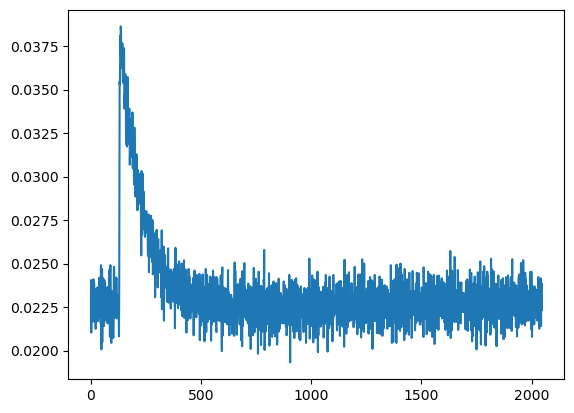

In [6]:
plt.plot(waveform)
plt.show()
plt.close()

## Preprocessing

Each pulse was normalized and downsampled&mdash;refered to as min-max normaliation in [1]&mdash;before being fed into the AP clustering model. 

Downsampling was performed using a discrete wavelet transform (DWT). DWT decomposes a waveform into "mutually orthogonal down-sampled sets of time-series coefficients by convolving the input signal with a given type of wavelet" [1]. DWT can be performed multiple times, represented by $l$ levels, on the same input signal [1]. The DWT outputs approximation coefficents (aC) and detail coefficents (dC), which describe the low and high frequency components of the input signal respectively. The DWT de-noises and reduces the dimension of an input waveform. 

The aC from the DWT effectivly works as a low-pass filter. DWT requires the use of a specific wavelet. León et al. utilized the Haar wavelet because "important information ... is contained in the rising edge and sharp turnover from the rising edge to the tail" for HPGe detectors [1]. While different detctors were used, we want to keep similar pulse artifacts as León et al. Future work could include exploring the perfromance of other wavelets, such as the Daubechies wavelets. 

In [7]:
# Apply DWT
wavelet = pywt.Wavelet('haar')
coeffs = pywt.wavedec(waveform, wavelet, level=3)
cA3, cD3, cD2, cD1 = coeffs # cA3 is smoothed with 1/8 length of normal time

prepulse_len_dwt = PRE_PULSE_LEN // 8

Below is a representation of the Haar wavelet. Note that the wavelet fucntion is essentially a step function and the scaling function does not scale the pulse in the wavelet window.

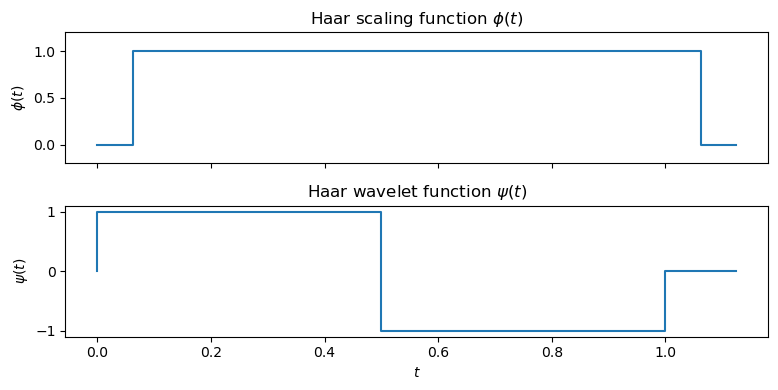

In [8]:
# Haar scaling and wavelet functions
phi, psi, x = wavelet.wavefun(level=3)

# Plot scaling and wavelet functions
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Scaling function
axes[0].step(x, phi, where='mid')
axes[0].set_title("Haar scaling function $\\phi(t)$")
axes[0].set_ylabel("$\\phi(t)$")
axes[0].set_ylim(-0.2, 1.2)

# Wavelet function
axes[1].step(x, psi)
axes[1].set_title("Haar wavelet function $\\psi(t)$")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$\\psi(t)$")

plt.tight_layout()
plt.show()

Below are the detail coefficents (cD) for each level of the DWT and the approximation coefficents (cA) for the final level, $l=3$. Note that $\text{cA}_3$ provides a downsampled representation of the pulse while the cD outputs show the high-frequency artifcats of the signal. 

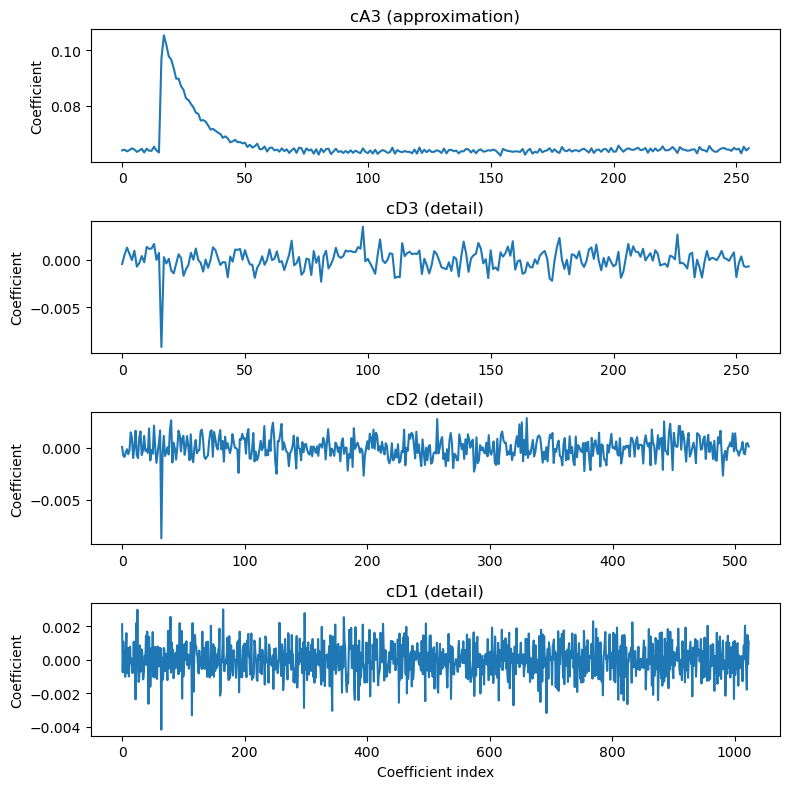

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(8, 8))

for ax, coeff, name in zip(
    axes,
    [cA3, cD3, cD2, cD1],
    ["cA3 (approximation)", "cD3 (detail)", "cD2 (detail)", "cD1 (detail)"]
):
    ax.plot(coeff)
    ax.set_title(name)
    ax.set_ylabel("Coefficient")

axes[-1].set_xlabel("Coefficient index")

plt.tight_layout()
plt.show()

Now we can apply normalize the pulse.

In [10]:
# Apply offset
offset = np.median(cA3[:(prepulse_len_dwt//2)])
baseline_pulse = np.subtract(cA3, offset)

In [11]:
# Find max or min
max_min = np.maximum(
    np.max(baseline_pulse),
    np.abs(np.min(baseline_pulse))
)

In [12]:
# Normalize to [-1,1]
norm_pulse = np.divide(baseline_pulse, max_min)

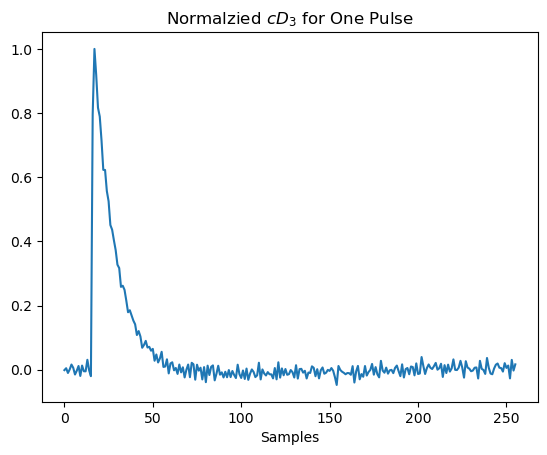

In [13]:
# Normalized pulse
plt.plot(norm_pulse)
plt.title(r'Normalzied $cD_3$ for One Pulse')
plt.xlabel('Samples')
plt.show()
plt.close()

Now the data is ready to be fed into the AP model. All pulses have be normalized to [-1,1] and downsampled from 2048 to 256 samples. This makes the each sample represents 6.4 $\mu\text{s}$.  

Below is a sample of 64 processed pulses.

![processed_pulses](../outputs/figs/norm_pulses_day16_chan3.svg "Processed Pulses")

# Unsupervised Clustering

## AP Overview

An unsupervised clustering algorthim was used to label different categories of pulses before expanding the classification abillity using an SVM.

The training and optimaztion of the model was run on CRONOS using 20 threads using the python script `apParamSweep.py`, which can be found at the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST). The script completed in 1 hr 21 min 29 s of wall-clock time, consuming 24.30 CPU-hours (87477.57 CPU seconds) with a peak memory usage of 4.47 GB RAM.

I changed the AP param sweep to give info on the size of the clusters. There is no reason to use the target of 100 clusters from [1] for this model. For each of the 12x12 (damping, preference) options, the param sweep saves the following information:

 * preference
 * damping
 * seed
 * n_clusters
 * converged
 * n_iter
 * n_singleton_clusters
 * fraction_singleton_clusters
 * fraction_singleton_events
 * min_cluster_size
 * max_cluster_size
 * mean_cluster_size
 * median_cluster_size

This will be used to determine the optimal parameters to run a stability test on using ARI. Finally, a "best" model can be determined using this information. 

***How AP works, why are we using this, `apParamSweep.py`.***

## AP Param Search

Now lets load the results of the AP param search:

In [106]:
ap_param_grid = pd.read_pickle(f'../data/20260819_ap_grid_day16_chan03_10000_20260803_1.pkl')

In [110]:
ap_param_grid['seed']

0      None
1      None
2      None
3      None
4      None
       ... 
139    None
140    None
141    None
142    None
143    None
Name: seed, Length: 144, dtype: object

In [107]:
ap_param_grid.head()

,preference,damping,seed,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
0,-27.941062,0.85,None,173,True,67,68,0.393064,0.0068,1,708,57.803468,9.0
1,-26.312706,0.85,None,180,True,103,69,0.383333,0.0069,1,708,55.555556,8.0
2,-24.684350,0.85,None,193,True,63,78,0.404145,0.0078,1,677,51.813472,8.0
3,-23.055993,0.85,None,208,True,109,84,0.403846,0.0084,1,639,48.076923,8.0
4,-21.427637,0.85,None,234,True,117,103,0.440171,0.0103,1,636,42.735043,6.0


In [108]:
ap_param_grid.describe()

,preference,damping,n_clusters,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.00000,144.0,144.000000,144.000000,144.000000
mean,-18.985102,0.920000,413.236111,148.090278,264.104167,0.553008,0.02641,1.0,779.368056,37.491745,3.750000
std,5.640792,0.044089,308.688292,78.665167,265.303302,0.146353,0.02653,0.0,901.621211,24.987901,3.198011
min,-27.941062,0.850000,64.000000,16.000000,51.000000,0.381215,0.00510,1.0,441.000000,8.291874,1.000000
25%,-23.463082,0.885000,194.000000,107.000000,78.000000,0.405797,0.00780,1.0,522.000000,20.593305,1.000000
50%,-18.985102,0.920000,286.500000,132.500000,144.500000,0.532051,0.01445,1.0,625.000000,35.101691,1.000000
75%,-14.507122,0.955000,492.750000,171.250000,318.000000,0.686672,0.03180,1.0,640.000000,51.546392,7.250000
max,-10.029142,0.990000,1206.000000,474.000000,968.000000,0.815789,0.09680,1.0,6778.000000,156.250000,9.000000


In [109]:
ap_param_grid[ap_param_grid['converged'] == False]

,preference,damping,seed,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size


We can see that there were 144 parameter combinations that we searched, all of whiched converged. The other parameters varied as expected. 

The goal is to find a parameter region where the clustering is stable and the clusters have a physically meaningful strucutre. 

### Old

Now lets make a plot of the parameter search and select the model which produced the closest to 100 clusters:

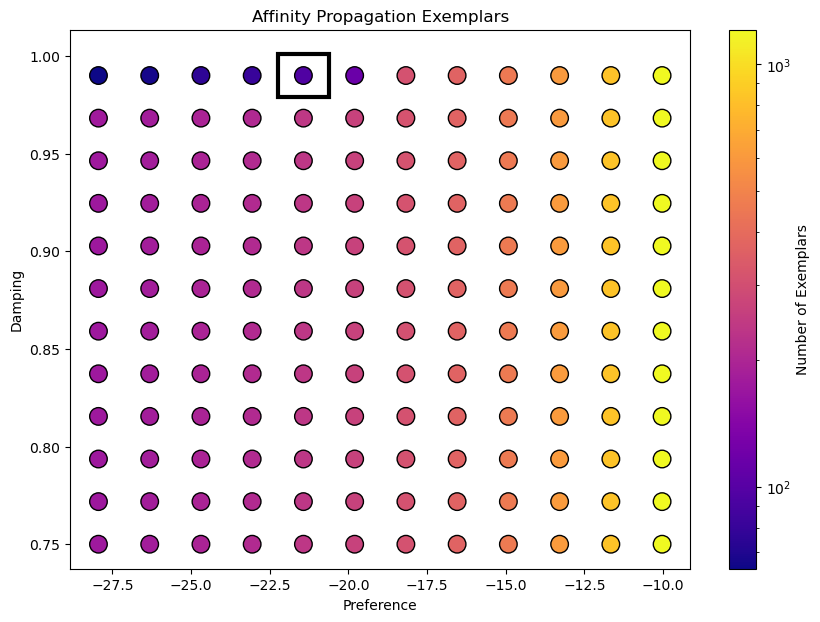

In [23]:
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    ap_param_grid['preference'],
    ap_param_grid['damping'],
    c=ap_param_grid['n_clusters'],
    cmap='plasma',
    norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(ap_param_grid['preference'].unique())).mean()
damp_step = np.diff(np.sort(ap_param_grid['damping'].unique())).mean()

rect = Rectangle(
    (
        ap_best_load['best_params']['preference'] - pref_step / 2,
        ap_best_load['best_params']['damping'] - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('../outputs/figs/ap_param_sweep.png')
#plt.savefig('../outputs/figs/ap_param_sweep.svg', format='svg', dpi=1200)

plt.show()
plt.close()

Here we see that the best model the parameter seach found. 

## Best AP Model Results

Okay I need to load the examplars from the best model. 

In [22]:
ap_best_load

{'model': AffinityPropagation(affinity='precomputed', damping=0.99, max_iter=500,
                     preference=-21.427636756987663, random_state=23),
 'labels': array([48, 48, 48, ..., 48, 14, 48]),
 'best_params': {'preference': -21.427636756987663, 'damping': 0.99},
 'target_clusters': 100,
 'wavelet': 'haar',
 'dwt_level': 3,
 'similarity_metric': 'l1',
 'normalization': 'max_abs',
 'median_similarity': -10.029142033107043}

Now we can load the best model. We can also information about what DWT was applied, the number of target clusters, and the performance of the grid searach. 

In [24]:
ap_model = ap_best_load['model']

In [27]:
ap_model

AffinityPropagation(affinity='precomputed', damping=0.99, max_iter=500,
                    preference=-21.427636756987663, random_state=23)

Now we can look at the performance of the best AP model. We can see that the 10 000 pulses formed 95 clusters.

In [43]:
print(f'Number of clusters: {len(ap_model.cluster_centers_indices_)}')
print(f'Number of pulses clustered: {ap_model.n_features_in_}')

Number of clusters: 95
Number of pulses clustered: 10000


We can look at the examplars for each cluster by looking at the `cluster_center_indices_` located in `data/day16_chan03_10000_20260803.npy`

In [44]:
# Pulse number from data/day16_chan03_10000_20260803.npy

ap_model.cluster_centers_indices_

array([ 171,  223,  252,  423,  515,  699,  724,  732,  736,  956, 1011,
       1066, 1162, 1238, 1241, 1309, 1458, 1587, 1615, 1645, 1708, 1719,
       1838, 1875, 1945, 1974, 2034, 2066, 2258, 2263, 2397, 2401, 2515,
       2821, 2924, 3016, 3060, 3089, 3147, 3466, 3479, 3701, 3903, 3948,
       3997, 4168, 4345, 4498, 4696, 4729, 4799, 4833, 4931, 5038, 5113,
       5274, 5555, 5766, 5784, 5823, 5956, 6138, 6272, 6347, 6513, 6545,
       6687, 6718, 6739, 6765, 6847, 6877, 6950, 7270, 7374, 7418, 7445,
       7511, 7586, 7641, 7984, 8403, 8547, 9174, 9177, 9346, 9386, 9388,
       9498, 9628, 9658, 9803, 9828, 9856, 9945])

And how many samples are in each cluster. 

In [75]:
counts = pd.Series(ap_model.labels_).value_counts()
print(counts.head(15))

48    5696
87    1568
53    1028
88     392
21     380
9      237
14     100
20      77
86      68
56      55
19      53
39      51
7       50
70      44
13      32
dtype: int64


In [78]:
print(f'Number of clusters with one pulse: {(counts == 1).sum()}')
print(f'Number of clusters with > one pulse: {len(counts) - (counts == 1).sum()}')

Number of clusters with one pulse: 73
Number of clusters with > one pulse: 22


In [77]:
counts[93]

4

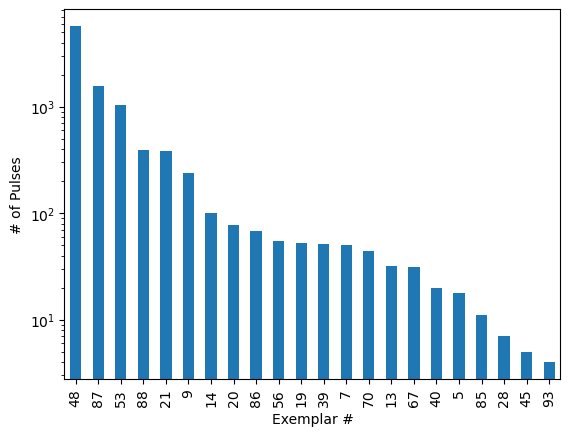

In [ ]:
counts_not_1 = counts[counts > 1]

counts_not_1.plot(kind='bar')
plt.semilogy()
plt.xlabel('Exemplar #')
plt.ylabel('# of Pulses')
plt.show()
plt.close()

# Manual Cluster Sorting

Now lets look at the clusters the AP model found and what seperates them. The AP model is clustering pulses that are most similar (after min-max normalization) in pulse shape. Any inforamtion about the differences between the clusters should indicate a difference in pulses shape.

## Cluster Properties

First I want to see if there is a difference between laser and non-laser events in this model. First we need to load the pulses.

In [80]:
pulses = np.load('../data/day16_chan03_10000_20260803.npy')

Now lets see how many pulses are laser pulses for the whole data set:

In [82]:
print(f"total laser : {np.count_nonzero(pulses['ig_laser'])} / {len(pulses['ig_laser'])} : {np.count_nonzero(pulses['ig_laser']) / len(pulses['ig_laser'])}")

total laser : 7012 / 10000 : 0.7012


48    5696
87    1568
53    1028
88     392
21     380
      ... 
31       1
30       1
29       1
27       1
94       1
Length: 95, dtype: int64

In [95]:
for _, idx in enumerate(counts):
    print(f'{_} : {idx}')

0 : 5696
1 : 1568
2 : 1028
3 : 392
4 : 380
5 : 237
6 : 100
7 : 77
8 : 68
9 : 55
10 : 53
11 : 51
12 : 50
13 : 44
14 : 32
15 : 31
16 : 20
17 : 18
18 : 11
19 : 7
20 : 5
21 : 4
22 : 1
23 : 1
24 : 1
25 : 1
26 : 1
27 : 1
28 : 1
29 : 1
30 : 1
31 : 1
32 : 1
33 : 1
34 : 1
35 : 1
36 : 1
37 : 1
38 : 1
39 : 1
40 : 1
41 : 1
42 : 1
43 : 1
44 : 1
45 : 1
46 : 1
47 : 1
48 : 1
49 : 1
50 : 1
51 : 1
52 : 1
53 : 1
54 : 1
55 : 1
56 : 1
57 : 1
58 : 1
59 : 1
60 : 1
61 : 1
62 : 1
63 : 1
64 : 1
65 : 1
66 : 1
67 : 1
68 : 1
69 : 1
70 : 1
71 : 1
72 : 1
73 : 1
74 : 1
75 : 1
76 : 1
77 : 1
78 : 1
79 : 1
80 : 1
81 : 1
82 : 1
83 : 1
84 : 1
85 : 1
86 : 1
87 : 1
88 : 1
89 : 1
90 : 1
91 : 1
92 : 1
93 : 1
94 : 1


## Manual Sorting

# New AP notes

 * AP param serach
    * each (pref, damping) pair:
       * run AP 
       * record seed
       * record 
         * convergance  
         * n_iter
         * n_clusters
         * n_singleton_clusters
         * fraction_singleton_clusters
         * fraction_singleton_events
         * min_cluster_size
         * max_cluster_size
         * mean_cluster_size
         * median_cluster_size
    * save AP grid dataframe  
 * Stability analysis (probably in AP param search)
    * Select candidate pararmeter points based on stabilty, cluster size, etc
    * For each candidate run an AP model with $N$ seeds
    * compare the labels
    * calcaulte ARI 
      * mean ARI
      * median ARI 
      * min ARI
      * std ARI
* Physical validation (probably in AP param search)
  * for stable AP models
    * determine menaigful differences for 
      * `ig_laser`
      * `multiplicity`
      * `energy`
* Manual labeling
  * select AP model
  * inspect exemplars
  * map AP clusters to physcial categories ($\approx 5$)
* Train SVM using manually labeled data
* Validate on held-out data


 

For now I will run the cluster sizess and singletons. I can adapt this to run with 5 seeds later but this will obviously increase the CPU time by 5x. First find promising params, then compare stabilty. Prorbaly make a new script for stability analysis

# Overview

Here is an overview of the pipeline for this. The pipeline is broken into individual scripts (described below) that do each part of the following:

 * Get pulses from raw data: `pulseGrabber.py`
 * Select $N$ pulses to train an ML model: `getNPulses.py`
 * Run a parameter seach to find the optimal AP model: `apParamSweep.py`
 * Manually sort clusters from the best AP model: ***TO DO***
 * Run a parameter seach to find the optimal SVM model: `svmParamSweep.py` (see [1] for more info when writing this)


* Get pulses using `pulseGrabber.py`. Does the following:
    * saves all pulses from each 10-min time chunk to a .npy file. If a file already exists then skip that chan/chunk pair. If you want to redo a selection, either put a different `save_directory` or delete the current directory/file(s). Saves the following informations:
        * `waveform`
            * waveform of pulses. Length of 2048 samples (128 prepulse, 1920 pulse)
            * np.float32 (pulse_len,)
        * `ig_laser`
            * Whether the laser was 
            * np.bool
        * `multiplicity`
            * Number of channels with simultaneous pulses
            * np.int32
        * `energy`
            * Energy of pulse after calibration corrections (see https://doi.org/10.1103/PhysRevD.111.052010 [2] for more info)
            * np.float32
        * `p0`
            * Calibration parameter (see [2])
            * np.float32
    * Each 10-min chunk of pulses is \approx$ 1&ndash;1.3 GB of pulses. All pulses arrays are stored in a dir in `/data_fast/chinkle/26_ml/allPulses/out_pulses_{day}_{all or chan list}`. Each channel and time chunk are saved independetly. File names are formated as following:
        * `{save_dir}/{time metadata from tdms}_{sig A/B}_{time chunk}_{chan}.npy`
            * ex all: `/data_fast/chinkle/26_ml/allPulses/out_pulses_33_all/20221129-030020.093762_A_000_02.npy`
            * ex one chan: `/data_fast/chinkle/26_ml/allPulses/out_pulses_16_ch3/20221106-231354.459620_A_004_03.npy`
    * Inputs (on command line):
        * `tdms_directory`
            * Directory where raw TDMS files are stored
            * Not required, default hard coded as day 16
        * `h5_directory`
            * Directory where associated h5 files are stored
            * Not required, default hard coded as day 16
        * `save_directory`
            * Directory where template pulses will be stored
            * Not required, default logic above
        * `threads`
            * Max threads to launch. Max 48 cores on CRONOS
            * Not required, default to 20 threads
        * `chans`
            * Channels to save pulses from. Seperate using spaces. Ex. --chans 0 1 2
            * Not required, default all chans

* Select $N$ pulses from a directory (typically one day) using `getNPulses.py`
    * Parse arguments as `args`
    * Set seed if provided
    * file_map = makeFileMap()
        * create a map of of (chunk, chan) $\rightarrow$ filename
        * inputs
            * `pulse_directory`
            * `channels`
    * dtype = getPulseDtype()
        * Set the `dtype` to save pulses
    * save_loc = makeSaveName(args)
        * get today's date, day, and channels. Create save_loc based on `save_directory`.
        * If the file already exists add `_#` at the end. 
        * inputs
            * `args`
    * pulses = samplePulse()
        * get $N$ samples from the file map
        * Look at each (chunk, channel) and sample randomly from that file as many times as that (chunk, channel) is in the file map
        * Return the pulses
        * inputs
            * `file_map`
            * `args.n_samples`
            * `dtype`
    * save `pulses` to `save_loc`
    * 
    * Inputs (on command line):
        * `save_directory`
            * Directory to save N pulses to. The filename will automatically generated be based on filename, chans (if included), and date
            * Not required, default `/data_fast/chinkle/26_ml/selectedPulses/`
        * `pulse_directory`
            * Directory to sample pulses from. Input data must follow from pulses saved using `pulseGrabber.py `
            * Required, no default
        * `n_samples`
            * Numer of samples to save
            * Not required, default 5000 
        * `chans`
            * Channel(s) to sample from. List with spaces. Ex: 0 2 10
            * Not required, default all chans
        * `seed`
            * Random seed
            * Not required, no default

        ***TODO: need to update for new `apParamSweep.py`***

* Load pulses from a npy array, pre-process, and run a parameter search for AP clustering using `apParamSweep.py`
    * Parse arguments as `args`
    * Load pulses from `args.pulse_directory`
    * Preprocess the pulses. We want to downsample the pusles before feeding into AP due to time and memory constraints.
        * Apply DWT to downsample $2048\rightarrow256$ samples
        * Normalize baseline to 0 and pulse height to 1
    * Calculate similarity matrix using an $\ell _1$ norm. See [1] for more info.
    * Set preferance and damping ranges
    * Run AP param search
        * Using multithreading run AP using various preferance and dampings. Run AP and return whether it converged, number of clusters, preferance, and damping. 
        * Inputs
            * param_grid
            * S
            * args
    * Convert to a df and save at `save_directory` based on the pulse_file given:
        * Save the same file name with `{todays date}\_ap\_grid_` before it
        * Ex:
            * input `/{pulse_dir}/day16_chan03_5000_20260729_filtered_norm.npy`
            * output `/{save_dir}/20260803_ap_grid_day16_chan03_5000_20260729_filtered_norm.pkl`
    * Inputs (on command line):
        * `pulse_file`
            * File where the selected pulses are stored. Input data must follow from pulses saved using `getNPulses.py `
            * Required, no default
        * `save_directory`
            * Directory where AP parameter search results will be stored
            * Not required, default dir: `/data_fast/chinkle/26_ml/apResults/`, filename generated as described above
        * `threads`
            * Max threads to launch. Max 48 on CRONOS
            * Not required, default 20 threads
        * `pref_range`
            * Minimum and maximum preference values. Must provide exactly two values.
            * Not required, default: [-10, min(S)] 
        * `damp_range`
            * Minimum and maximum damping values. Must provide exactly two values.
            * Not required, default: [0.75, 0.99]'
        * `seed`
            * Random seed
            * Not required, no default
        * `max_iter`
            * Max iterations to run AP
            * Not required, default 500
        * `converge_iter`
            *  Number of iterations with no change in the number of estimated clusters that stops the convergence
            *  Not required, default 15
        * `target_clusters`
            *  Target number of clusters for AP
            *  Not required, default 100


 ## Notes
Calibrated energy is not needed per inwook. Going to take it out (maybe, maybe jsut keep it) when I rerun everything. 

Use `drift_corrected_energy_substr_corr_rescaled` instead. Changed `calibrated_energy` to `energy`, `calibration_parameters` to `p0` (likely will keep). 

changed `pulseGrabberChan.py` to `pulseGrabber.py`

redoing `getNPulses.py` to be modular and a good python program

not actually temporally uniform. it is uniform across chunks and then uniform across pulses in a chunk. slight difference here.

maybe do 10k instead of 5k

okay, I have made the pipeline through AP. I am going to delete the current stuff for day 16 (just leave day 33 andn write about day 16 chan 3) and rerun using the full pipeline. 


## Overall flowchart
Assuming no files have been made for the day yet do the following:

 * Run `pulseGrabber.py`
     * Need to know `h5` and `tdms` files for these days
     * Specify channel 3
     * Will create a directory with all the pulses
 * Run `getNPulses.py` to select 10 000 pulses from the create direcrtory above
 * Find a "best" AP model
     * Run `apParamSweep.py`
     * Choose the best performing paramters
     * Run a stablility test on these using ARI ***new script for this??***
 * Analyze the AP model and form $\approx 5$ clusters
     * See if there is a correlation with:
         * `ig_laser`
         * `multiplicity`
         * `energy`
     * Group based on 1 pulse, pile-up, etc
 * Run an SVM param sweep ***need to make a script for this***
 * Validate on other data --> use results from `pulseGrabber.py` and an updated/modified `getNPulses.py`
 

### Notes

I ran `/usr/bin/time -v python3 pulseGrabber.py --chans 3` for day 16. I used the defaults for everything else (20 threads, auto `save_dir`, hard coded day 16 `tdms` and `h5`. 

Fist run didn't work, there was no `drift_corrected_energy_substr_corr_rescaled`. I will find one that has this. 

In [29]:
import pandas as pd

In [30]:
#h5Day16 = '/beest_data/finalProcessingBlinded-20250519/magcycle-33-221128/processed/chewed_metadata_20221129-224243.971075_Sig_A.h5'
h5Day16 = r'/beest_data/finalProcessingBlinded-20250519/magcycle-16-221106/processed/chewed_metadata_20221106-223352.840919_Sig_A.h5'

In [31]:
df16_3_processed = pd.read_hdf(h5Day16, key=f'data_channel3')

In [32]:
print(df16_3_processed.columns.tolist())


['filename', 'trigger_position_corrected', 'trigger_position', 'trigger_value', 'trigger_level_in_ADC', 'head0', 'head1', 'head2', 'tail1', 'tail2', 'head0_std', 'head1_std', 'head2_std', 'tail1_std', 'tail2_std', 'max0', 'max1', 'max2', 'fp1', 'fp3', 'fp5', 'fp8', 'fp9', 'mt0', 'mt1', 'mt2', 'mt50p0', 'mt50p1', 'mt50p2', 'mt20p0', 'mt20p1', 'mt20p2', 'int0', 'int1', 'int2', 'flattop1_mean', 'flattop2_mean', 'flattop1_std', 'flattop2_std', 'trig_pos_corr_fit', 'head2_fit', 'flat2_fit', 'trig_pos_corr_err', 'head2_err', 'max2_err', 'lsq_err', 'time', 'ig_laser', 'ig_laser_pileup', 'multiplicity', 'coincident_channels', 'coincident_positions', 'sumV', 'multiplicity_delayed', 'coincident_channels_delayed', 'coincident_positions_delayed', 'sumV_delayed', 'calibrated_laser_substr_corr', 'calibrated_physics_substr_corr', 'calibrated_energy_substr_corr', 'drift_corrected_energy_substr_corr', 'drift_corrected_energy_substr_corr_rescaled']


This looks good. I will use this. I got rid of `p0` because it was causing issues and its not needed. 

`pulseGrabber.py` worked. Some of the times didn't work (this is to be expected, every other one had some issues). I just did channel 3 day 16. 

Channels that didnt work: 3, 14, 23,26, 53, 64, 71, 95, 102, 121

Rerunning once to see if it will do any different ones this time. No difference on the new one.



In [33]:
memKb = 1077316 #kb
userTime = 54775.44 #s
sysTime = 6859.52 #s
cpuPer = 1543 #%

In [34]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 core total)')

Memory used:  1.08 GB
user time: 912.92 min = 15.22 hour
sys time: 114.33 min = 1.91 hour
CPU time: 61634.96 sec = 17.12 hr
cpu percentage per core: 77.15% (20 core total)


The script completed in 1 h 6 min 33 s of wall-clock time, consuming 17.1 CPU-hours (61,635 CPU seconds) with a peak memory usage of 1.03 GiB RAM.

Saved at `/data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/`

Now I am running `getNPulses.py` with 10 000 pulses. 

`/usr/bin/time -v python3 getNPulses.py --pulse_directory /data_fast/chinkle/26_ml/allPulses/out_pulses_16_chans_3/ --seed 23 --chans 3 --n_samples 10000`


In [35]:
memKb = 1489392 #kb
userTime = 2.10 #s
sysTime = 120.09 #s
cpuPer = 97 #%

In [36]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer}% ')

Memory used:  1.49 GB
user time: 0.04 min = 0.00 hour
sys time: 2.00 min = 0.03 hour
CPU time: 122.19 sec = 2.04 min = 0.03 hr
cpu percentage per core: 97% 


The script completed in 2 min 5.34 s of wall-clock time, consuming 2.04 CPU-minutes (122.19 CPU seconds) with a peak memory usage of 1.49 GiB RAM.

Saved at `/data_fast/chinkle/26_ml/selectedPulses/day16_chan03_10000_20260803.npy`

Now I ran `apParamSweep.py`. The ap param sweep is saved at `/data_fast/chinkle/26_ml/apResults/20260819_ap_grid_day16_chan03_10000_20260803.pkl`

#### new AP search

I ran `apParamSweep.py`.

Preference values were calculated from the 5th to 50th percentile of the similarity matrix, $S$, without the diagonal. Damping values were [0.85, 0.99]. This time I am saving the labels for the best as well.

AP grid search saved at `/data_fast/chinkle/26_ml/apResults/20260818_ap_grid_day16_chan03_10000_20260803.pkl`

In [97]:
memKb = 4469264 #kb
userTime = 85718.47 #s
sysTime = 1759.10 #s
cpuPer = 1789 #%

In [98]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 threads used) ')

Memory used:  4.47 GB
user time: 1428.64 min = 23.81 hour
sys time: 29.32 min = 0.49 hour
CPU time: 87477.57 sec = 1457.96 min = 24.30 hr
cpu percentage per core: 89.45% (20 threads used) 


The script completed in 1 hr 21 min 29 s of wall-clock time, consuming 24.30 CPU-hours (87477.57 CPU seconds) with a peak memory usage of 4.47 GB RAM.

# Old AP analysis

In [39]:
results_df = pd.read_pickle('/data_fast/chinkle/26_ml/apResults/20260803_ap_grid_day16_chan03_10000_20260803.pkl')

In [40]:
results_df.head()

,preference,damping,n_clusters,converged
0,-50.00000,0.75,90,True
1,-69.20551,0.75,62,True
2,-88.41102,0.75,47,True
3,-107.61653,0.75,44,True
4,-126.82204,0.75,35,True


preference       -50.0
damping       0.924545
n_clusters          92
converged         True
Name: 96, dtype: object


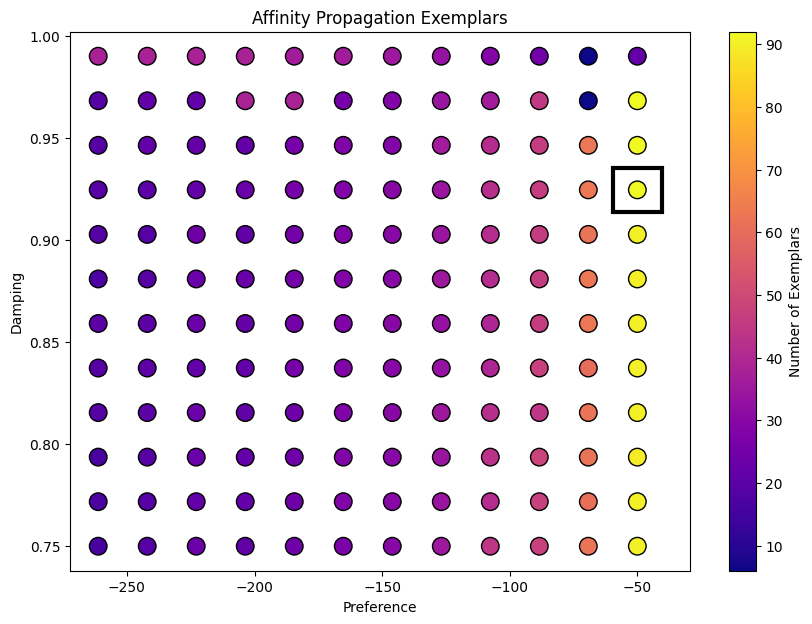

In [41]:
import matplotlib as mt 
from matplotlib.patches import Rectangle

target_clusters = 100
valid_df = results_df.dropna(subset=["n_clusters"]).copy()
best_idx = (
    valid_df["n_clusters"] - target_clusters
).abs().idxmin()

best_point = valid_df.loc[best_idx]

best_pref = best_point["preference"]
best_damp = best_point["damping"]
best_clusters = best_point["n_clusters"]

print(best_point)


plt.figure(figsize=(10, 7))

sc = plt.scatter(
    results_df["preference"],
    results_df["damping"],
    c=results_df["n_clusters"],
    cmap='plasma',
    #norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(results_df["preference"].unique())).mean()
damp_step = np.diff(np.sort(results_df["damping"].unique())).mean()

rect = Rectangle(
    (
        best_pref - pref_step / 2,
        best_damp - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('ap_param_sweep.png')

plt.show()
plt.close()

In [42]:
results_df['preference'].min()

-261.26061025145464

In [43]:
results_df['preference'].max()

-50.0

#### AP analysis 2

I will rerun with a different preference range : (max(S), -20) and damping range: (0.65, 0.99). 

I ran `apParamSweep.py` again. The ap param sweep is saved at `/data_fast/chinkle/26_ml/apResults/20260804_ap_grid_day16_chan03_10000_20260803.pkl`

In [44]:
memKb = 4800408 #kb
userTime = 53959.87 #s
sysTime = 4716.27 #s
cpuPer = 1890 #%

In [45]:
print(f'Memory used: {memKb * 1e-6: .2f} GB')
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')
print(f'cpu percentage per core: {cpuPer/20}% (20 threads used) ')

Memory used:  4.80 GB
user time: 899.33 min = 14.99 hour
sys time: 78.60 min = 1.31 hour
CPU time: 58676.14 sec = 977.94 min = 16.30 hr
cpu percentage per core: 94.5% (20 threads used) 


The script completed in 51 min 44.44 s of wall-clock time, consuming 16.3 CPU-hours (58,676.14 CPU seconds) with a peak memory usage of 4.80 GiB RAM.

In [46]:
results_df_2 = pd.read_pickle('/data_fast/chinkle/26_ml/apResults/20260804_ap_grid_day16_chan03_10000_20260803.pkl')

In [47]:
results_df_2.head()

,preference,damping,n_clusters,converged
0,-20.000000,0.65,262,True
1,-41.932783,0.65,120,True
2,-63.865566,0.65,66,True
3,-85.798348,0.65,45,True
4,-107.731131,0.65,41,True


preference   -20.0
damping       0.99
n_clusters     115
converged     True
Name: 132, dtype: object


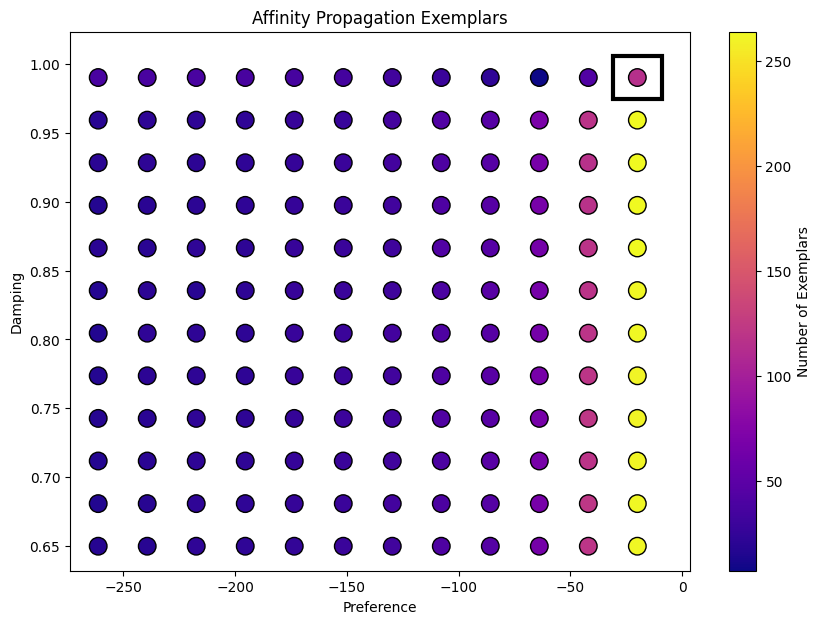

In [48]:
target_clusters = 100
valid_df = results_df_2.dropna(subset=["n_clusters"]).copy()
best_idx = (
    valid_df["n_clusters"] - target_clusters
).abs().idxmin()

best_point = valid_df.loc[best_idx]

best_pref = best_point["preference"]
best_damp = best_point["damping"]
best_clusters = best_point["n_clusters"]

print(best_point)


plt.figure(figsize=(10, 7))

sc = plt.scatter(
    results_df_2["preference"],
    results_df_2["damping"],
    c=results_df_2["n_clusters"],
    cmap='plasma',
    #norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Number of Exemplars')

ax = plt.gca()

# Estimate box size from grid spacing
pref_step = np.diff(np.sort(results_df_2["preference"].unique())).mean()
damp_step = np.diff(np.sort(results_df_2["damping"].unique())).mean()

rect = Rectangle(
    (
        best_pref - pref_step / 2,
        best_damp - damp_step / 2
    ),
    pref_step,
    damp_step,
    fill=False,
    linewidth=3
)

ax.add_patch(rect)

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('ap_param_sweep.png')

plt.show()
plt.close()